Data generation

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from copy import deepcopy
from rashomon import hasse, extract_pools, loss, aggregate, AIS, MCMC

M = 2
R = np.array([4, 3])

num_profiles = 2**M
profiles, profile_map = hasse.enumerate_profiles(M)

all_policies = hasse.enumerate_policies(M, R)
num_policies = len(all_policies)

sigma_00 = None
# mu_00 = np.array([0])
mu_00 = np.array([5])
var_00 = np.array([1])

# Profile (0, 1)
sigma_01 = np.array([[1]])
# mu_01 = np.array([-0.1])
mu_01 = np.array([10])
var_01 = np.array([1])

# Profile (1, 0)
sigma_10 = np.array([[1, 0]])
# mu_10 = np.array([-0.2, -0.3])
mu_10 = np.array([-10, 15])
var_10 = np.array([1, 1])

# Profile (1, 1)
sigma_11 = np.array([[0, 1], [0, np.inf]])
# mu_11 = np.array([0.2, 0.3, -0.1, -0.1])
mu_11 = np.array([20, 30, 5, 10])
var_11 = np.array([1, 1, 1, 1])

sigma = [sigma_00, sigma_01, sigma_10, sigma_11]
mu = [mu_00, mu_01, mu_10, mu_11]
var = [var_00, var_01, var_10, var_11]

In [60]:
policies_profiles = {}
policies_profiles_masked = {}
policies_ids_profiles = {}
pi_policies = {}
pi_pools = {}
for k, profile in enumerate(profiles):

    policies_temp = [(i, x) for i, x in enumerate(all_policies) if hasse.policy_to_profile(x) == profile]
    unzipped_temp = list(zip(*policies_temp))
    policies_ids_k = list(unzipped_temp[0])
    policies_k = list(unzipped_temp[1])
    policies_profiles[k] = deepcopy(policies_k)
    policies_ids_profiles[k] = policies_ids_k

    profile_mask = list(map(bool, profile))

    # Mask the empty arms
    for idx, pol in enumerate(policies_k):
        policies_k[idx] = tuple([pol[i] for i in range(M) if profile_mask[i]])
    policies_profiles_masked[k] = policies_k

    if np.sum(profile) > 0:
        pi_pools_k, pi_policies_k = extract_pools.extract_pools(policies_k, sigma[k])
        if len(pi_pools_k.keys()) != mu[k].shape[0]:
            print(f"Profile {k}. Expected {len(pi_pools_k.keys())} pools. Received {mu[k].shape[0]} means.")
        pi_policies[k] = pi_policies_k
        # pi_pools_k has indicies that match with policies_profiles[k]
        # Need to map those indices back to all_policies
        pi_pools[k] = {}
        for x, y in pi_pools_k.items():
            y_full = [policies_profiles[k][i] for i in y]
            y_agg = [all_policies.index(i) for i in y_full]
            pi_pools[k][x] = y_agg
    else:
        pi_policies[k] = {0: 0}
        pi_pools[k] = {0: [0]}

In [61]:
def generate_data(mu, var, n_per_pol, all_policies, pi_policies, M):
    num_data = num_policies * n_per_pol
    X = np.zeros(shape=(num_data, M))
    D = np.zeros(shape=(num_data, 1), dtype='int_')
    y = np.zeros(shape=(num_data, 1))

    idx_ctr = 0
    for k, profile in enumerate(profiles):
        policies_k = policies_profiles[k]

        for idx, policy in enumerate(policies_k):
            policy_idx = [i for i, x in enumerate(all_policies) if x == policy]

            pool_id = pi_policies[k][idx]
            mu_i = mu[k][pool_id]
            var_i = var[k][pool_id]
            y_i = np.random.normal(mu_i, var_i, size=(n_per_pol, 1))

            start_idx = idx_ctr * n_per_pol
            end_idx = (idx_ctr + 1) * n_per_pol

            X[start_idx:end_idx, ] = policy
            D[start_idx:end_idx, ] = policy_idx[0]
            y[start_idx:end_idx, ] = y_i

            idx_ctr += 1

    return X, D, y

In [62]:
num_samples_per_feature = 500

np.random.seed(680)
X, D, y = generate_data(mu, var, num_samples_per_feature, all_policies, pi_policies, M)
policy_means = loss.compute_policy_means(D, y, num_policies)

In [67]:
H = np.inf
theta = 20
lamb = 1
R_set, R_profiles = aggregate.RAggregate(M, R, H, D, y, theta, reg=lamb, verbose=True)

(0, 0) 19.07413098071051
Profile (0, 0) has 1 objects in Rashomon set
(0, 1) 19.165232199845757
Adaptive
Profile (0, 1) took 0.0015139579772949219 s adaptively
Profile (0, 1) has 2 objects in Rashomon set
(1, 0) 19.23980186265632
Adaptive
Profile (1, 0) took 0.003268003463745117 s adaptively
Profile (1, 0) has 4 objects in Rashomon set
(1, 1) 19.500998066592807
Adaptive
Profile (1, 1) took 0.012389183044433594 s adaptively
Profile (1, 1) has 4 objects in Rashomon set
Finding feasible combinations
Min = 9.0073827272593, Max = 48.696735669208685


In [68]:
R_set

[[np.int64(0), np.int64(0), np.int64(0), np.int64(0)],
 [np.int64(0), np.int64(0), np.int64(0), np.int64(1)],
 [np.int64(0), np.int64(0), np.int64(0), np.int64(2)],
 [np.int64(0), np.int64(0), np.int64(0), np.int64(3)],
 [np.int64(0), np.int64(0), np.int64(1), np.int64(0)],
 [np.int64(0), np.int64(0), np.int64(1), np.int64(1)],
 [np.int64(0), np.int64(0), np.int64(1), np.int64(2)],
 [np.int64(0), np.int64(0), np.int64(1), np.int64(3)],
 [np.int64(0), np.int64(1), np.int64(0), np.int64(0)],
 [np.int64(0), np.int64(1), np.int64(0), np.int64(1)],
 [np.int64(0), np.int64(1), np.int64(0), np.int64(2)],
 [np.int64(0), np.int64(1), np.int64(0), np.int64(3)],
 [np.int64(0), np.int64(1), np.int64(1), np.int64(0)],
 [np.int64(0), np.int64(1), np.int64(1), np.int64(1)],
 [np.int64(0), np.int64(1), np.int64(1), np.int64(2)],
 [np.int64(0), np.int64(1), np.int64(1), np.int64(3)]]

In [69]:
anchors = AIS.build_anchor_states(R_set, R_profiles, M, R)
prof_idx_of_policy, profiles = AIS.build_profile_index_of_policy(all_policies, hasse.policy_to_profile)

RPS_states = AIS.raggregate_to_states((R_set, R_profiles), profiles)
score_s = AIS.make_score_s_expneg_raw(
    D=D,
    y=y,
    M=M,
    R=R,
    prof_idx_of_policy = prof_idx_of_policy,
    policies=all_policies,
    policy_means=policy_means,
    reg=lamb,
    lattice_edges=None,   # or your edges
    beta=1.0,             # exp(-loss)
    prior_logprob=lambda state: 0.0
)

In [71]:
mcmc_res = MCMC.load_mcmc_res("./toy_50000.pkl.gz")

In [ ]:
log_alpha = [score_s(A) for A in anchors]
mcmc_res = MCMC.run_mcmc(score_s, RPS_states, log_alpha, n_chains=1, steps=200000, burnin=500, thin=5, seed=2, min_len=1)
# MCMC.save_mcmc_res(mcmc_res, "./toy_50000.pkl.gz")

KeyboardInterrupt: 

In [60]:
sample=mcmc_res["samples"]

Text(0.5, 1.0, '50000 MCMC run')

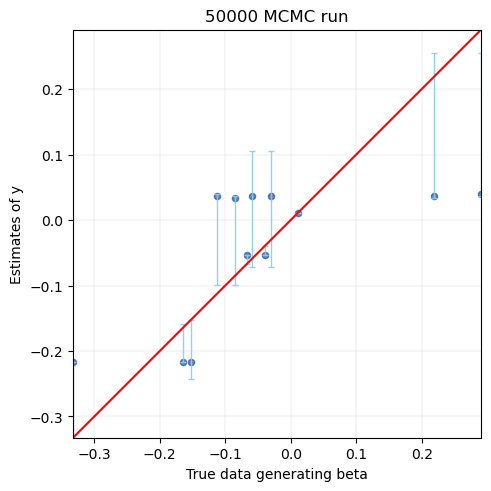

In [81]:
df = MCMC.policy_means_matrix_from_mcmc(
    mcmc_res["samples"],
    all_policies,                     # global list/array of policies (length P)
    policy_means,                 # np.ndarray [P,2] = [sum_y, count]
    prof_idx_of_policy,           # length-P array: policy_id -> profile k
    R_per=R,                        # np.ndarray of arm levels (includes control)
    M=M,
    lattice_edges=None,           # pass None if unused
    policy_labels=None            # optional column names; defaults to policy indices (0..P-1)
)

out = MCMC.summarize_policy_means(df)

MCMC.plot_pred_vs_true(out,                         # output from summarize_policy_means
                      policy_means,
                      point_alpha=0.6,
                      point_color="#0b3d91",     # dark blue
                      bar_color="#87ceeb",       # sky blue
                      line_color="red",
                      figsize=(5,5))

plt.title("50000 MCMC run")

Text(0.5, 1.0, 'RPS of length 35')

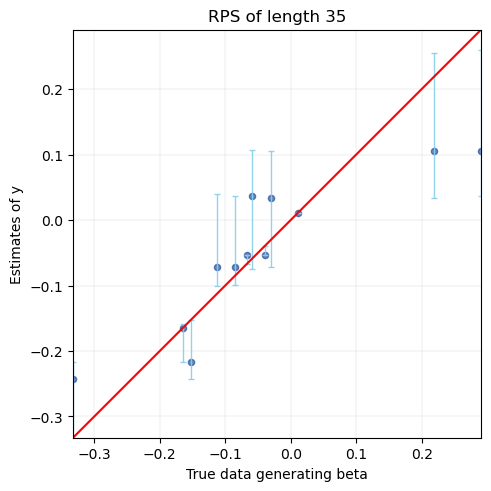

In [82]:
RPS_df = MCMC.policy_means_matrix_from_mcmc(
    RPS_states,
    all_policies,                     # global list/array of policies (length P)
    policy_means,                 # np.ndarray [P,2] = [sum_y, count]
    prof_idx_of_policy,           # length-P array: policy_id -> profile k
    R_per=R,                        # np.ndarray of arm levels (includes control)
    M=M,
    lattice_edges=None,           # pass None if unused
    policy_labels=None            # optional column names; defaults to policy indices (0..P-1)
)

RPS_out = MCMC.summarize_policy_means(RPS_df)

MCMC.plot_pred_vs_true(RPS_out,                         # output from summarize_policy_means
                      policy_means,
                      point_alpha=0.6,
                      point_color="#0b3d91",     # dark blue
                      bar_color="#87ceeb",       # sky blue
                      line_color="red",
                      figsize=(5,5))

plt.title("RPS of length 35")

In [53]:
np.unique(df[:][11])

array([-0.1128555 , -0.09930026, -0.08626925, -0.07195011,  0.03691074,
        0.03945962])

In [72]:
# find the true partition in MCMC samples
target_by_profile = {
    0: ((0,0), sigma_00),
    1: ((0,1), sigma_01),
    2: ((1,0), sigma_10),
    3: ((1,1), sigma_11)
}

true_sample = MCMC.find_states_matching_targets(mcmc_res,R,M,target_by_profile)
print(true_sample["fraction"])
# find the RPS states in MCMC samples
RPS_post = []
for partition in RPS_states:
    target_by_profile = {
        0: ((0,0), partition[0].B),
        1: ((0,1), partition[1].B),
        2: ((1,0), partition[2].B),
        3: ((1,1), partition[3].B)
    }
    true_sample = MCMC.find_states_matching_targets(mcmc_res,R,M,target_by_profile)
    RPS_post.append(true_sample["fraction"])
    
normalized_RPS_post = [i / sum(RPS_post) for i in RPS_post]

0.0030303030303030303


In [73]:
# calculate the exact posterior of RPS states
RPS_post_exact = []

for partition in RPS_states:
    RPS_post_exact.append(score_s(partition))

normalized_RPS_post_exact = [i / sum(RPS_post_exact) for i in RPS_post_exact]

In [74]:
# Enumerate all states and keep score
from rashomon import AIS
losses = AIS.enumerate_all_states_and_losses(
    profiles=profiles,
    R=R,
    M=M,
    policies=all_policies,
    policy_means=policy_means,
    prof_idx_of_policy=prof_idx_of_policy,
    D=D, y=y,
    reg=lamb, normalize=0,
    lattice_edges=None,
    max_states=None  # or an integer cap to safeguard
)

In [75]:
sig = [AIS.state_signature(i[0]) for i in losses]

In [76]:
true_posterior = [np.exp(-i[1]) for i in losses]
norm_true_post = [i/sum(true_posterior) for i in true_posterior]

In [77]:
true_post = []
RPS_test = []
for partition in RPS_states:
    signature = AIS.state_signature(partition)
    idx = sig.index(signature)
    RPS_test.append(true_posterior[idx])
    true_post.append(norm_true_post[idx])

In [11]:
RPS_test_norm = [i/sum(RPS_test) for i in RPS_test]

In [62]:
pd.DataFrame({'RPS_estimates_exact':normalized_RPS_post_exact, 'MCMC estimates': normalized_RPS_post, 'ture posterior': true_post, 'RPS test': RPS_test_norm})

,RPS_estimates_exact,MCMC estimates,ture posterior,RPS test
0,0.173479,0.175766,0.165015,0.173479
1,0.065350,0.061274,0.062162,0.065350
2,0.064414,0.059896,0.061272,0.064414
3,0.063820,0.070285,0.060706,0.063820
4,0.024053,0.020460,0.022879,0.024053
5,0.008849,0.007527,0.008418,0.008849
6,0.008719,0.008269,0.008293,0.008719
7,0.064248,0.063925,0.061113,0.064248
8,0.024202,0.023852,0.023021,0.024202
9,0.023856,0.024382,0.022692,0.023856


(0.007526767730308492, 0.1757659281246687)

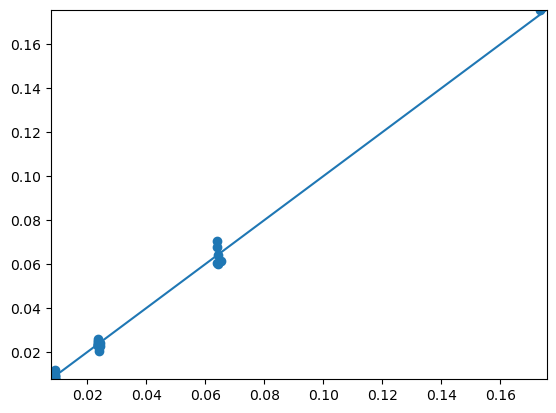

In [66]:
plt.scatter(normalized_RPS_post_exact, normalized_RPS_post) 
x=np.array(normalized_RPS_post_exact)
y=np.array(normalized_RPS_post)
lims = [
    min(x.min(), y.min()),
    max(x.max(), y.max()),
]
plt.plot(lims, lims)   # y = x
plt.xlim(lims)
plt.ylim(lims)

In [12]:
data_generating_partition = []

data_generating_partition.append(AIS.ProfilePart(cov_ids = tuple((0,0)), B = sigma[0]))
data_generating_partition.append(AIS.ProfilePart(cov_ids = tuple((0,1)), B = sigma[1]))
data_generating_partition.append(AIS.ProfilePart(cov_ids = tuple((1,0)), B = sigma[2]))
data_generating_partition.append(AIS.ProfilePart(cov_ids = tuple((1,1)), B = sigma[3]))

In [81]:
for partition in RPS_states:
    if AIS.states_equal(partition, data_generating_partition):
        print("yes")
        signature = AIS.state_signature(partition)
        idx = sig.index(signature)
        print(norm_true_post[idx])


yes
0.4702911304075283


In [79]:
indices = [index for index, value in enumerate(norm_true_post) if value > 0.4]

In [80]:
losses[50][0][0].B
print(losses[50][0][1].B)
print(losses[50][0][2].B)
print(losses[50][0][3].B)

[[1.]]
[[1. 0.]]
[[ 0.  1.]
 [ 0. inf]]


In [27]:
np.sort(norm_true_post)

array([1.39878091e-94, 3.80155411e-94, 3.13444630e-90, 8.51868019e-90,
       1.41282876e-87, 3.83973282e-87, 1.64740110e-83, 4.47724472e-83,
       5.30336925e-80, 1.44132974e-79, 1.18840099e-75, 3.22979148e-75,
       5.35663058e-73, 1.45580490e-72, 6.24599343e-69, 1.69751259e-68,
       5.68174690e-66, 1.54368892e-65, 1.54416379e-65, 4.19537966e-65,
       6.91484638e-62, 1.87929093e-61, 5.10686943e-61, 1.38792576e-60,
       2.15419024e-51, 5.85277675e-51, 5.85457716e-51, 1.59064564e-50,
       2.62171034e-47, 7.12518570e-47, 1.93622991e-46, 5.26221278e-46,
       1.74507072e-35, 4.74268753e-35, 4.74347725e-35, 1.28916439e-34,
       3.91042688e-31, 1.06276110e-30, 1.06293807e-30, 2.88881307e-30,
       1.76259633e-28, 4.79031798e-28, 4.79111563e-28, 1.30211137e-27,
       2.05524069e-24, 5.58565579e-24, 5.58658587e-24, 1.51830128e-23,
       7.08835108e-07, 1.92585296e-06, 1.92644538e-06, 1.92676616e-06,
       5.23401068e-06, 5.23488221e-06, 5.23649255e-06, 1.42271659e-05,
      

In [32]:
true_post

[]